# Pipeline 1 - Dates Matching

The first pipeline will automate the following actions.<br>
INPUTS: 
* AOI
* PERIOD
* OUTPUT FOLDER (output will be organized by AOI)

ACTIONS:
1. Open the AOI
2. Create the S2 dataframe with cloud cover for the AOI and dates
3. Create the SWOT dataframe with the possible mosaics
4. Match SWOT and S2 dates, ordered by cloud cover
5. Create output structure in the AOI folder (/ref_masks, /OPERA, /dataframes)



## Imports

In [ ]:
%load_ext autoreload
%autoreload 2

from swot_toolkit.pipe1 import prepare_aoi_dataframes


## Pipeline 1

In [2]:
AOI = "/data/swot/AOIs/Curua-Una.kml"
DATE_RANGE = ("2024-01-01", "2025-09-30")
OUTPUT_DIR = "/data/swot/output/"


Output directory created at: /data/swot/output/Curua-Una
Searching for Sentinel-2 scenes intersecting the AOI...
S2 tile not provided. Guessing the best tile...
Tile 21MYS has 0 null values.
Tile 21MZT has 8375556 null values.
Tile 21MYT has 7417500 null values.
Tile 21MZS has 7428696 null values.
Assessing clouds in Sentinel-2 scenes...


  0%|          | 0/142 [00:00<?, ?it/s]

Searching for OPERA satellite data intersecting the AOI...
Found 232 OPERA satellite overpasses intersecting the AOI.
Searching for SWOT Raster_100 data intersecting the AOI...
Creating SWOT mosaics...


  0%|          | 0/28 [00:00<?, ?it/s]

Saving dataframes to /data/swot/output/Curua-Una/dfs...


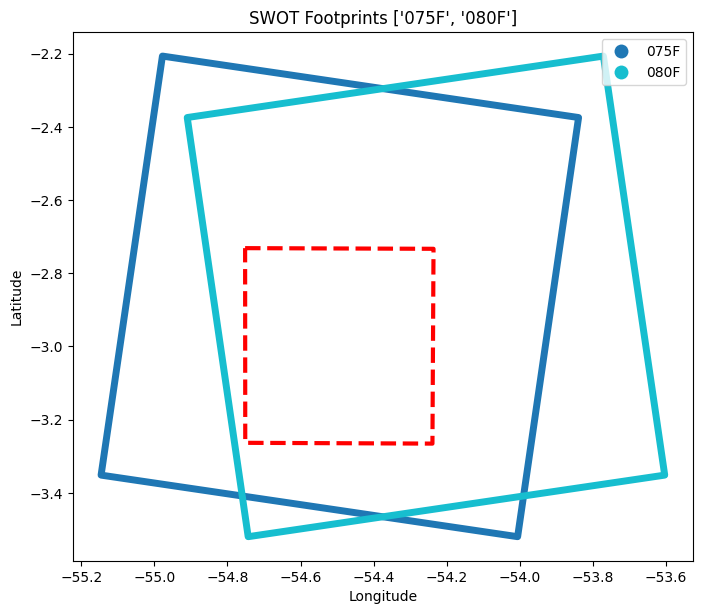

In [161]:
output_dir = prepare_aoi_dataframes(AOI, DATE_RANGE, OUTPUT_DIR)

## Analyze results

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import planetary_computer as pc
from odc.stac import stac_load

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.planetary import search_s2


In [8]:
output_dir = Path(OUTPUT_DIR) / "Curua-Una"
matches = pd.read_parquet(output_dir / "dfs/swot_s2_matches.parquet")


matches.sort_values("valid_pxls", ascending=False).iloc[:10]

,date,datetime,tile,valid_pxls,OPERA,delta
swot_mosaic_date,,,,,,
2024-07-13,2024-07-14,2024-07-14 13:57:09.024,21MYS,0.996257,S2B,1 days 13:57:09.024000
2024-09-24,2024-09-27,2024-09-27 13:57:01.024,21MYS,0.961070,S2A,3 days 13:57:01.024000
2025-08-14,2025-08-13,2025-08-13 13:57:21.025,21MYS,0.878888,S2C,-1 days +13:57:21.025000
2025-08-14,2025-08-18,2025-08-18 13:57:09.024,21MYS,0.854218,"S2B, S2A",4 days 13:57:09.024000
2025-09-04,2025-09-02,2025-09-02 14:01:11.025,21MYS,0.775533,S2C,-2 days +14:01:11.025000
2024-12-06,2024-12-01,2024-12-01 13:57:09.024,21MYS,0.755402,S2B,-5 days +13:57:09.024000
2024-06-22,2024-06-24,2024-06-24 13:57:09.024,21MYS,0.731047,S2B,2 days 13:57:09.024000
2025-07-13,2025-07-09,2025-07-09 13:57:09.024,21MYS,0.702701,"S2B, S2A",-4 days +13:57:09.024000
2024-07-13,2024-07-09,2024-07-09 13:57:11.024,21MYS,0.685627,S2A,-4 days +13:57:11.024000


### Choose a mosaic date to check the S2 items (figs generated in output dir)

In [81]:
MOSAIC_DATE = "2024-09-24"

In [86]:
import json

In [ ]:

s2_matches = matches.loc[MOSAIC_DATE].sort_values("date")
begin_date = s2_matches["date"].astype("str").iloc[0]
end_date = s2_matches["date"].astype("str").iloc[-1]
aoi_geom = read_kml_geometry(AOI)[0]
date_range = (begin_date, end_date)

results = s2_search = search_s2(aoi_geom, date_range, s2_matches["tile"].iloc[0])


In [83]:
cube = stac_load(
    items=results,
    bands=["B04", "B03", "B02"],
    bbox=aoi_geom.bounds,
    patch_url=pc.sign,
    dtype="uint16",
    nodata=0,
    resolution=100,
    preserve_original_order=True,
)

In [84]:
fig, ax = plt.subplots(figsize=(10, 10))
for item in results:

    time = pd.to_datetime(item.properties["datetime"][:-1])

    s2_img = cube.sel(time=time).to_array() / 10000
    s2_img.plot.imshow(ax=ax, rgb="variable", vmin=0, vmax=0.5)

    fname = item.id + "_thumb.png"
    fig.savefig(output_dir / "figs/" / fname, dpi=150)
    ax.clear()
fig.clear()



<Figure size 1000x1000 with 0 Axes>

### Selection of Dates

In [87]:
S2_IDS = {
    "2025-08-14": "S2B_MSIL2A_20250818T135709_R067_T21MYS_20250818T172904_thumb.png",
    "2024-09-24": "S2A_MSIL2A_20240927T135701_R067_T21MYS_20240927T190725_thumb",
}

# dump S2_IDS to the output root of directory as a json file
with open(output_dir / "S2_IDS.json", "w") as f:
    json.dump(S2_IDS, f, indent=4)




In [89]:
s2_img.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 21S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32721"]]')